In [23]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [24]:
torch.manual_seed(42)
np.random.seed(42)

In [25]:
data_dir = "dogs-vs-cats/train/train"
img_size = 64

X = []
y = []

for file in os.listdir(data_dir):

    path = os.path.join(data_dir, file)

    img = cv2.imread(path)

    if img is None:
        continue

    img = cv2.resize(img, (img_size, img_size))
    img = img / 255.0
    img = img.flatten()

    X.append(img)

    if "cat" in file:
        y.append(0)
    else:
        y.append(1)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (25000, 12288)


In [26]:
print(len(X))
print(len(y))
print(X.shape)
print(y.shape)

25000
25000
(25000, 12288)
(25000,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

In [29]:
class ANN(nn.Module):

    def __init__(self):

        super(ANN, self).__init__()

        self.layer1 = nn.Linear(img_size*img_size*3, 128)
        self.relu1 = nn.ReLU()

        self.layer2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()

        self.layer3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = self.layer1(x)
        x = self.relu1(x)

        x = self.layer2(x)
        x = self.relu2(x)

        x = self.layer3(x)
        x = self.sigmoid(x)

        return x
    
model = ANN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [30]:
epochs = 10

train_losses = []
test_accuracies = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()

    optimizer.step()

    train_losses.append(loss.item())

    # kiểm tra accuracy
    model.eval()

    with torch.no_grad():

        preds = model(X_test)

        preds = (preds > 0.5).float()

        acc = (preds.eq(y_test).sum() / y_test.size(0)).item()

        test_accuracies.append(acc)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | Acc: {acc*100:.2f}%")

Epoch 1/10 | Loss: 0.6928 | Acc: 51.08%
Epoch 2/10 | Loss: 0.7060 | Acc: 50.30%
Epoch 3/10 | Loss: 1.7357 | Acc: 50.30%
Epoch 4/10 | Loss: 0.7441 | Acc: 49.70%
Epoch 5/10 | Loss: 0.9872 | Acc: 49.70%
Epoch 6/10 | Loss: 0.9319 | Acc: 49.70%
Epoch 7/10 | Loss: 0.6998 | Acc: 50.30%
Epoch 8/10 | Loss: 0.7309 | Acc: 50.30%
Epoch 9/10 | Loss: 0.7499 | Acc: 50.30%
Epoch 10/10 | Loss: 0.7125 | Acc: 55.98%


In [31]:
model.eval()

with torch.no_grad():

        preds = model(X_test)

        preds = (preds > 0.5).float()

        acc = (preds.eq(y_test).sum() / y_test.size(0)).item()

        test_accuracies.append(acc)

print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | Acc: {acc*100:.2f}%")

Epoch 10/10 | Loss: 0.7125 | Acc: 55.98%


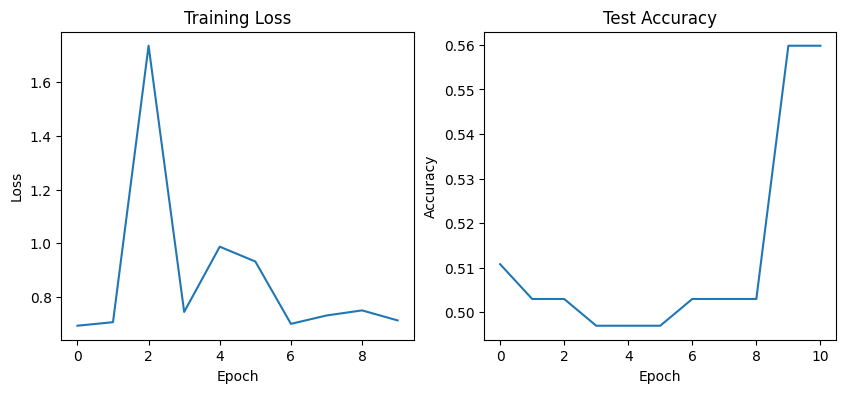

In [33]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(test_accuracies)
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()